The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Scale-free networks

In this chapter, we'll work with data from an online social network, and use a Watts-Strogatz graph to model it. The WS model has characteristics of a small world network, like the data, but it has low variability in the number of neighbors from node to node, unlike the data.

This discrepancy is the motivation for a network model developed by Barabási and Albert. The BA model captures the observed variability in the number of neighbors, and it has one of the small world properties, short path lengths, but it does not have the high clustering of a small world network.

The chapter ends with a discussion of WS and BA graphs as explanatory models for small world networks.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap04.ipynb).

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')

In [3]:
from utils import decorate, savefig

# Set the random seed so the notebook 
# produces the same results every time.
np.random.seed(17)

In [4]:
# make a directory for figures
!mkdir -p figs

## Social network data

Watts-Strogatz graphs are intended to model networks in the natural and social sciences. In their original paper, Watts and Strogatz looked at the network of film actors (connected if they have appeared in a movie together); the electrical power grid in the western United States; and the network of neurons in the brain of the roundworm *C. elegans*. They found that all of these networks had the high connectivity and low path lengths characteristic of small world graphs.

In this section we'll perform the same analysis with a different dataset, a set of Facebook users and their friends. If you are not familiar with Facebook, users who are connected to each other are called "friends", regardless of the nature of their relationship in the real world.

I'll use data from the Stanford Network Analysis Project (SNAP), which shares large datasets from online social networks and other sources. Specifically, I'll use their Facebook data (from J. McAuley and J. Leskovec, "Learning to Discover Social Circles in Ego Networks", NIPS, 2012), which includes 4039 users and 88,234 friend relationships among them. It is available from the SNAP website at <https://thinkcomplex.com/snap>.

In [5]:
download('https://snap.stanford.edu/data/facebook_combined.txt.gz')

The data file contains one line per edge, with users identified by integers from 0 to 4038. Here's the code that reads the file:

In [6]:
def read_graph(filename):
    G = nx.Graph()
    array = np.loadtxt(filename, dtype=int)
    G.add_edges_from(array)
    return G

NumPy provides a function called `loadtxt` that reads the given file and returns the contents as a NumPy array. The parameter `dtype` indicates that the "data type" of the array is `int`.

Then we use `add_edges_from` to iterate the rows of the array and make edges. Here are the results:

In [7]:
fb = read_graph('facebook_combined.txt.gz')
n = len(fb)
m = len(fb.edges())
n, m

(4039, 88234)

The node and edge counts are consistent with the documentation of the dataset.

Now we can check whether this dataset has the characteristics of a small world graph: high clustering and low path lengths.

In Chapter 3 we wrote a function to compute the network average clustering coefficient. NetworkX provides a function called `average_clustering`, which does the same thing a little faster.

But for larger graphs, they are both too slow, taking time proportional to $n k^2$, where $n$ is the number of nodes and $k$ is the number of neighbors each node is connected to.

Fortunately, NetworkX provides a function that estimates the clustering coefficient by random sampling. We can import it like this:

In [8]:
from networkx.algorithms.approximation import average_clustering

The following function does something similar for path lengths.

In [9]:
def sample_path_lengths(G, nodes=None, trials=1000):
    """Choose random pairs of nodes and compute the path length between them.

    G: Graph
    nodes: list of nodes to choose from
    trials: number of pairs to choose

    returns: list of path lengths
    """
    if nodes is None:
        nodes = list(G)
    else:
        nodes = list(nodes)
        
    pairs = np.random.choice(nodes, (trials, 2))
    lengths = [nx.shortest_path_length(G, *pair) 
               for pair in pairs]
    return lengths

`G` is a graph, `nodes` is the list of nodes to sample from, and `trials` is the number of random paths to sample. If `nodes` is `None`, we sample from the entire graph.

`pairs` is a NumPy array of randomly chosen nodes with one row for each trial and two columns.

The list comprehension enumerates the rows in the array and computes the shortest distance between each pair of nodes. The result is a list of path lengths.

`estimate_path_length` generates a list of random path lengths and returns their mean:

In [10]:
def estimate_path_length(G, nodes=None, trials=1000):
    return np.mean(sample_path_lengths(G, nodes, trials))

I'll use `average_clustering` to compute $C$:

In [11]:
C = average_clustering(fb)
C

0.607

And `estimate_path_length` to compute $L$:

In [12]:
L = estimate_path_length(fb)
L

np.float64(3.717)

The clustering coefficient is about 0.61, which is high, as we expect if this network has the small world property.

And the average path is 3.7, which is quite short in a network of more than 4000 users. It's a small world after all.

Now let's see if we can construct a WS graph that has the same characteristics as this network.

## WS Model

In the Facebook dataset, the average number of edges per node is about 22. Since each edge is connected to two nodes, the average degree is twice the number of edges per node:

In [13]:
n = len(fb)
m = len(fb.edges())
k = int(round(2*m/n))
k

44

We can make a WS graph with `n=4039` and `k=44`. When `p=0`, we get a ring lattice. The number of edges is a little bigger than in the dataset because we have to round `k` to an integer.

In [14]:
lattice = nx.watts_strogatz_graph(n, k, p=0)
len(lattice), len(lattice.edges())

(4039, 88858)

In this graph, clustering is high: `C` is 0.72, compared to 0.61 in the dataset.

In [15]:
C, average_clustering(lattice)

(0.607, 0.723)

But `L` is 47, much higher than in the dataset!

In [16]:
L, estimate_path_length(lattice)

(np.float64(3.717), np.float64(47.088))

With `p=1` we get a random graph:

In [17]:
random_graph = nx.watts_strogatz_graph(n, k, p=1)

In the random graph, `L` is 2.6, even shorter than in the dataset (3.7), but `C` is only 0.012, so that's no good.

In [18]:
C, average_clustering(random_graph)

(0.607, 0.012)

In [19]:
L, estimate_path_length(random_graph)

(np.float64(3.717), np.float64(2.591))

By trial and error, we find that when `p=0.05` we get a WS graph with high clustering and low path length:

In [20]:
ws = nx.watts_strogatz_graph(n, k, 0.05, seed=15)

In this graph `C` is 0.63, a bit higher than in the dataset, and `L` is 3.3, a bit lower than in the dataset. So this graph models the small world characteristics of the dataset well.

In [21]:
C, average_clustering(ws)

(0.607, 0.632)

In [22]:
L, estimate_path_length(ws)

(np.float64(3.717), np.float64(3.264))

So far, so good.

## Degree

If the WS graph is a good model for the Facebook network, it should have the same average degree across nodes, and ideally the same variance in degree.

This function returns a list of degrees in a graph, one for each node:

In [23]:
def degrees(G):
    """List of degrees for nodes in `G`.
    
    G: Graph object
    
    returns: list of int
    """
    return [G.degree(u) for u in G]

The mean degree in model is 44, which is close to the mean degree in the dataset, 43.7.

In [24]:
np.mean(degrees(fb)), np.mean(degrees(ws))

(np.float64(43.69101262688784), np.float64(44.0))

However, the standard deviation of degree in the model is 1.4, which is not close to the standard deviation in the dataset, 52.4. Oops.

In [25]:
np.std(degrees(fb)), np.std(degrees(ws))

(np.float64(52.41411556737521), np.float64(1.4309215628189869))

What's the problem? To get a better view, we have to look at the **distribution** of degrees, not just the mean and standard deviation.

I'll represent the distribution of degrees with a `Pmf` object, which is defined in the `empiricaldist` library. `Pmf` stands for "probability mass function"; if you are not familiar with this concept, you might want to read Chapter 3 of *Think Stats, 2nd edition* at <https://thinkcomplex.com/ts2>.

In [26]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

Briefly, a `Pmf` maps from values to their probabilities. A `Pmf` of degrees is a mapping from each possible degree, $d$, to the fraction of nodes with degree $d$.

As an example, I'll construct a graph with nodes 1, 2, and 3 connected to a central node, 0:

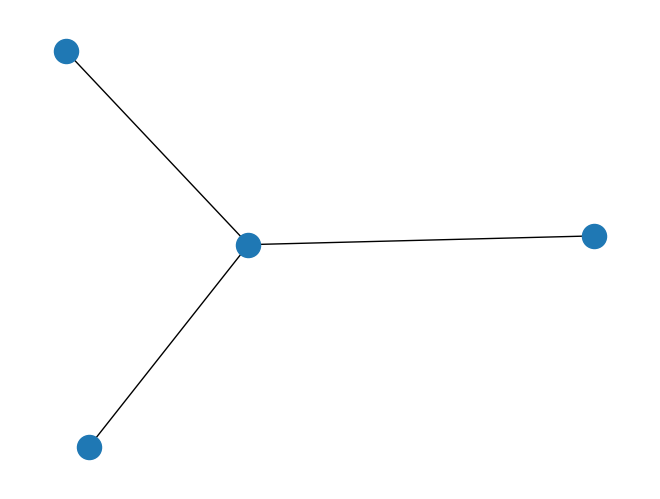

In [27]:
G = nx.Graph()
G.add_edge(1, 0)
G.add_edge(2, 0)
G.add_edge(3, 0)
nx.draw(G)

Here's the list of degrees in this graph:

In [28]:
degrees(G)

[1, 3, 1, 1]

Node 0 has degree 3, the others have degree 1. Now I can make a `Pmf` that represents this degree distribution:

In [29]:
from empiricaldist import Pmf

pmf = Pmf.from_seq(degrees(G))
pmf

,probs
1,0.75
3,0.25


The result is a `Pmf` object that maps from each degree to a fraction or probability. In this example, 75% of the nodes have degree 1 and 25% have degree 3.

We can visualize the distribution as a histogram:

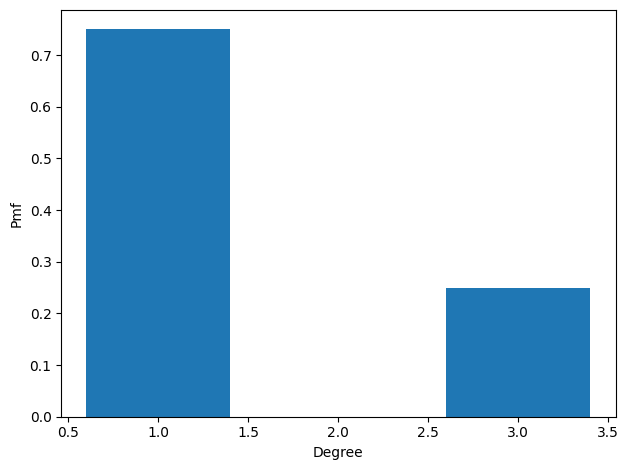

In [30]:
pmf.bar()
decorate(xlabel='Degree',
         ylabel='Pmf')

Now we can make a `Pmf` that contains node degrees from the dataset, and compute the mean and standard deviation:

In [31]:
pmf_fb = Pmf.from_seq(degrees(fb))
pmf_fb.mean(), pmf_fb.std()

(np.float64(43.69101262688785), np.float64(52.41411556737521))

And the same for the WS model:

In [32]:
pmf_ws = Pmf.from_seq(degrees(ws))
pmf_ws.mean(), pmf_ws.std()

(np.float64(44.00000000000001), np.float64(1.4309215628189869))

We can also use the `Pmf` to look up the fraction of nodes with exactly 1 neighbor.

In [33]:
pmf_fb(1), pmf_ws(1)

(np.float64(0.018568952711067097), 0)

The following figure shows the PMF of degree in the Facebook dataset and in the WS model.

Saving figure to file figs/chap04-1


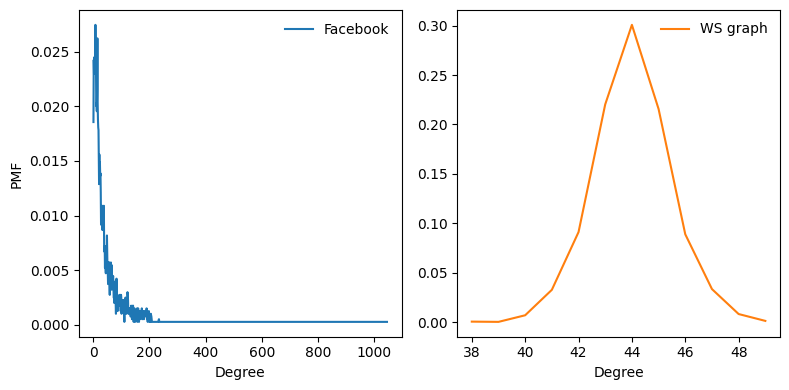

In [34]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
pmf_fb.plot(label='Facebook', color='C0')
decorate(xlabel='Degree', ylabel='PMF')

plt.subplot(1,2,2)
pmf_ws.plot(label='WS graph', color='C1')
decorate(xlabel='Degree')

savefig('figs/chap04-1')

The two distributions are very different.

In the WS model, most users have about 44 friends; the minimum is 38 and the maximum is 49. That's not much variation. In the dataset, there are many users with only 1 or 2 friends, but one has more than 1000!

Distributions like this, with many small values and a few very large values, are called **heavy-tailed**.

## Heavy-tailed distributions

Heavy-tailed distributions are a common feature in many areas of complexity science and they will be a recurring theme of this book.

We can get a clearer picture of a heavy-tailed distribution by plotting it on a log-log axis, as shown in the following figure. This transformation emphasizes the tail of the distribution; that is, the probabilities of large values.

Saving figure to file figs/chap04-2


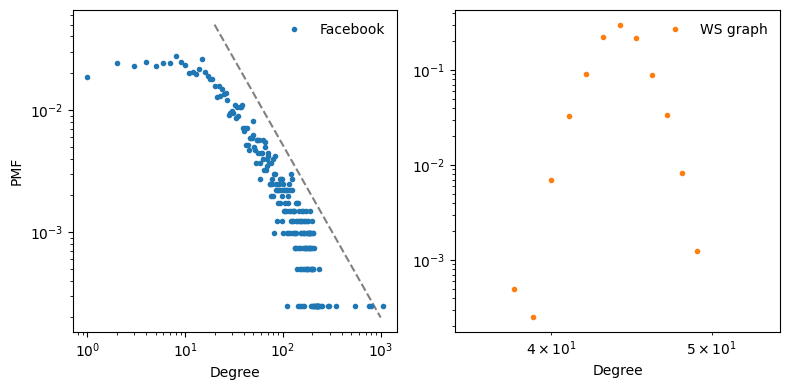

In [35]:
plt.figure(figsize=(8,4))
options = dict(ls='', marker='.')

plt.subplot(1,2,1)
plt.plot([20, 1000], [5e-2, 2e-4], color='gray', linestyle='dashed')

pmf_fb.plot(label='Facebook', color='C0', **options)
decorate(xscale='log', yscale='log',
         xlabel='Degree', ylabel='PMF')

plt.subplot(1,2,2)
pmf_ws.plot(label='WS graph', color='C1', **options)
decorate(xlim=[35, 55], 
         xscale='log', yscale='log',
         xlabel='Degree')

savefig('figs/chap04-2')

Under this transformation, the data fall approximately on a straight line, which suggests that there is a **power law** relationship between the largest values in the distribution and their probabilities. Mathematically, a distribution obeys a power law if $$\mathrm{PMF}(k) \sim k^{-\alpha}$$ where $\mathrm{PMF}(k)$ is the fraction of nodes with degree $k$, $\alpha$ is a parameter, and the symbol $\sim$ indicates that the PMF is asymptotic to $k^{-\alpha}$ as $k$ increases.

If we take the log of both sides, we get $$\log \mathrm{PMF}(k) \sim -\alpha \log k$$ So if a distribution follows a power law and we plot $\mathrm{PMF}(k)$ versus $k$ on a log-log scale, we expect a straight line with slope $-\alpha$, at least for large values of $k$.

The log-log scale doesn't help the WS graph.

All power law distributions are heavy-tailed, but there are other heavy-tailed distributions that don't follow a power law. We will see more examples soon.

But first, we have a problem: the WS model has the high clustering and low path length we see in the data, but the degree distribution doesn't resemble the data at all. This discrepancy is the motivation for our next topic, the Barabási-Albert model.

## Barabási-Albert model

In 1999 Barabási and Albert published a paper, "Emergence of Scaling in Random Networks", that characterizes the structure of several real-world networks, including graphs that represent the interconnectivity of movie actors, web pages, and elements in the electrical power grid in the western United States. You can download the paper from <https://thinkcomplex.com/barabasi>.

They measure the degree of each node and compute $\mathrm{PMF}(k)$, the probability that a vertex has degree $k$. Then they plot $\mathrm{PMF}(k)$ versus $k$ on a log-log scale. The plots fit a straight line, at least for large values of $k$, so Barabási and Albert conclude that these distributions are heavy-tailed.

They also propose a model that generates graphs with the same property. The essential features of the model, which distinguish it from the WS model, are:

Growth:

:   Instead of starting with a fixed number of vertices, the BA model starts with a small graph and adds vertices one at a time.

Preferential attachment:

:   When a new edge is created, it is more likely to connect to a vertex that already has a large number of edges. This "rich get richer" effect is characteristic of the growth patterns of some real-world networks.

Finally, they show that graphs generated by the Barabási-Albert (BA) model have a degree distribution that obeys a power law.

Graphs with this property are sometimes called **scale-free networks**, for reasons I won't explain; if you are curious, you can read more at <https://thinkcomplex.com/scale>.

NetworkX provides a function that generates BA graphs. In the next section, I'll show you how it works, and we'll use it to model the Facebook data.

## Generating BA graphs

Here is a version of `barabasi_albert_graph` from NetworkX, with some changes I made to make it easier to read:

In [36]:
# modified version of the NetworkX implementation from
# https://github.com/networkx/networkx/blob/master/networkx/generators/random_graphs.py

import random

def barabasi_albert_graph(n, k, seed=None):
    """Constructs a BA graph.
    
    n: number of nodes
    k: number of edges for each new node
    seed: random seen
    """
    if seed is not None:
        random.seed(seed)
    
    G = nx.empty_graph(k)
    targets = set(range(k))
    repeated_nodes = []

    for source in range(k, n):

        G.add_edges_from(zip([source]*k, targets))

        repeated_nodes.extend(targets)
        repeated_nodes.extend([source] * k)

        targets = _random_subset(repeated_nodes, k)

    return G

The parameters are `n`, the number of nodes we want, and `k`, the number of edges each new node gets (which will turn out to be the average number of edges per node).

We start with a graph that has `k` nodes and no edges. Then we initialize two variables:

`targets`:

:   The list of `k` nodes that will be connected to the next node. Initially `targets` contains the original `k` nodes; later it will contain a random subset of nodes.

`repeated_nodes`:

:   A list of existing nodes where each node appears once for every edge it is connected to. When we select from `repeated_nodes`, the probability of selecting any node is proportional to the number of edges it has.

Each time through the loop, we add edges from the source to each node in `targets`. Then we update `repeated_nodes` by adding each target once and the new node `k` times.

Finally, we choose a subset of the nodes to be targets for the next iteration. Here's the definition of `_random_subset`:

In [37]:
def _random_subset(repeated_nodes, k):
    """Select a random subset of nodes without repeating.
    
    repeated_nodes: list of nodes
    k: size of set
    
    returns: set of nodes
    """
    targets = set()
    while len(targets) < k:
        x = random.choice(repeated_nodes)
        targets.add(x)
    return targets

Each time through the loop, `_random_subset` chooses from `repeated_nodes` and adds the chosen node to `targets`. Because `targets` is a set, it automatically discards duplicates, so the loop only exits when we have selected `k` different nodes.

Now we can generate a BA graph with the same number of nodes and edges as the Facebook data:

In [38]:
n = len(fb)
m = len(fb.edges())
k = int(round(m/n))
n, m, k

(4039, 88234, 22)

The parameters are `n`, the number of nodes to generate, and `k`, the number of edges each node starts with when it is added to the graph. I chose `k=22` because that is the average number of edges per node in the dataset. Providing a random seed means we'll get the same graph every time.

In [39]:
ba = barabasi_albert_graph(n, k, seed=15)

The resulting graph has 4039 nodes and 21.9 edges per node.

In [40]:
len(ba), len(ba.edges()), len(ba.edges())/len(ba)

(4039, 88374, 21.88016835850458)

Since every edge is connected to two nodes, the average degree is 43.8, very close to the average degree in the dataset, 43.7.

In [41]:
np.mean(degrees(fb)), np.mean(degrees(ba))

(np.float64(43.69101262688784), np.float64(43.76033671700916))

And the standard deviation of degree is 41.0, which is a bit less than in the dataset, 52.4, but it is much better than what we got from the WS graph, 1.4.

In [42]:
np.std(degrees(fb)), np.std(degrees(ba))

(np.float64(52.41411556737521), np.float64(41.03760075705614))

Let's take a look at the degree distribution.

In [43]:
pmf_ba = Pmf.from_seq(degrees(ba))

Looking at the PMFs on a linear scale, we see one difference, which is that the BA model has no nodes with degree less than `k`, which is 22.

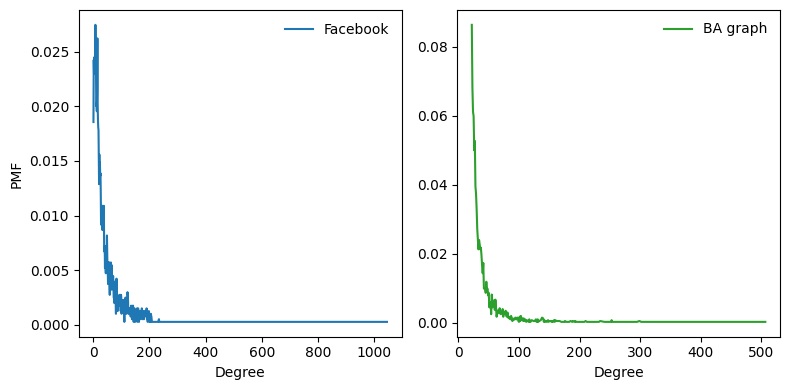

In [44]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
pmf_fb.plot(label='Facebook', color='C0')
decorate(xlabel='Degree', ylabel='PMF')

plt.subplot(1,2,2)
pmf_ba.plot(label='BA graph', color='C2')
decorate(xlabel='Degree')

The following figure shows the degree distributions for the Facebook dataset and the BA model on a log-log scale.

Saving figure to file figs/chap04-3


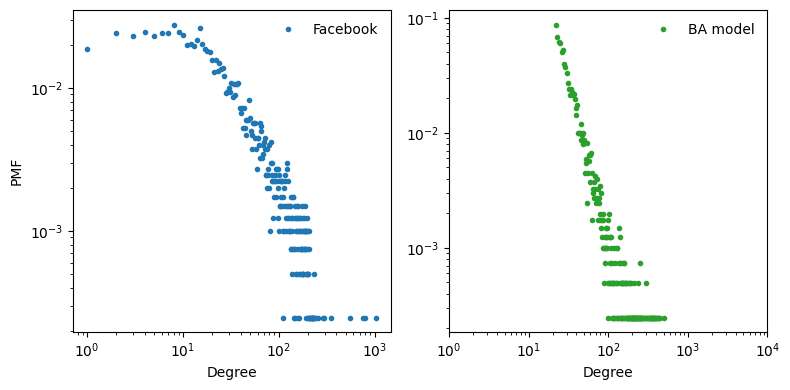

In [45]:
plt.figure(figsize=(8,4))
options = dict(ls='', marker='.')

plt.subplot(1,2,1)

pmf_fb.plot(label='Facebook', color='C0', **options)
decorate(xlabel='Degree', ylabel='PMF',
         xscale='log', yscale='log')

plt.subplot(1,2,2)

pmf_ba.plot(label='BA model', color='C2', **options)
decorate(xlabel='Degree',
         xlim=[1, 1e4],
         xscale='log', yscale='log')

savefig('figs/chap04-3')

The model is not perfect; in particular, it deviates from the data when `k` is less than 10. But the tail looks like a straight line, which suggests that this process generates degree distributions that follow a power law.

So the BA model is better than the WS model at reproducing the degree distribution. But does it have the small world property?

In this example, the average path length, $L$, is $2.5$, which is even more "small world" than the actual network, which has $L=3.7$. So that's good, although maybe too good.

In [46]:
L, estimate_path_length(ba)

(np.float64(3.717), np.float64(2.481))

On the other hand, the clustering coefficient, $C$, is $0.048$, not even close to the value in the dataset, $0.61$. So that's a problem.

In [47]:
C, average_clustering(ba)

(0.607, 0.048)

The following table summarizes these results. The WS model captures the small world characteristics, but not the degree distribution. The BA model captures the degree distribution, at least approximately, and the average path length, but not the clustering coefficient.

|             | Facebook | WS model | BA model |
|-------------|---------:|---------:|---------:|
| C           |     0.61 |     0.63 |    0.048 |
| L           |     3.72 |     3.26 |     2.48 |
| Mean degree |     43.7 |       44 |     43.8 |
| Std degree  |     52.4 |      1.4 |     41.0 |
| Power law?  |    maybe |       no |      yes |

In the exercises at the end of this chapter, you can explore other models intended to capture all of these characteristics.

## Cumulative distributions

The previous figure represents the degree distribution by plotting the probability mass function (PMF) on a log-log scale. That's how Barabási and Albert present their results and it is the representation used most often in articles about power law distributions. But it is not the best way to look at data like this.

A better alternative is a **cumulative distribution function** (CDF), which maps from a value, $x$, to the fraction of values less than or equal to $x$.

Given a `Pmf`, the simplest way to compute a cumulative probability is to add up the probabilities for values up to and including $x$:

In [48]:
def cumulative_prob(pmf, x):
    """Computes the cumulative probability of `x`.
    
    Total probability of all values <= x.
    
    returns: float probability
    """
    ps = [pmf[value] for value in pmf.qs if value<=x]
    return np.sum(ps)

For example, given the degree distribution in the dataset, `pmf_fb`, we can compute the fraction of users with 25 or fewer friends:

In [49]:
cumulative_prob(pmf_fb, 25)

np.float64(0.5060658578856152)

The result is close to 0.5, which means that the median number of friends is about 25.

Similarly, the total probability for all values up to and including 11 is 0.258, so the 25th percentile is about 11.

In [50]:
cumulative_prob(pmf_fb, 11)

np.float64(0.2577370636296113)

And the 75th percentile is about 57.  That is, about 75% of users have 57 friends or fewer.

In [51]:
cumulative_prob(pmf_fb, 57)

np.float64(0.751671205743996)

CDFs are better for visualization because they are less noisy than PMFs. Once you get used to interpreting CDFs, they provide a clearer picture of the shape of a distribution than PMFs.

The `empiricaldist` library provides a class called `Cdf` that represents a cumulative distribution function. We can use it to compute the CDF of degree in the dataset, and in the two models.

In [52]:
from empiricaldist import Cdf

In [53]:
cdf_fb = Cdf.from_seq(degrees(fb), name='Facebook')

In [54]:
cdf_ws = Cdf.from_seq(degrees(ws), name='WS model')

In [55]:
cdf_ba = Cdf.from_seq(degrees(ba), name='BA model')

The following figure shows the degree CDF for the Facebook dataset along with the WS model (left) and the BA model (right). The x-axis is on a log scale.

Saving figure to file figs/chap04-4


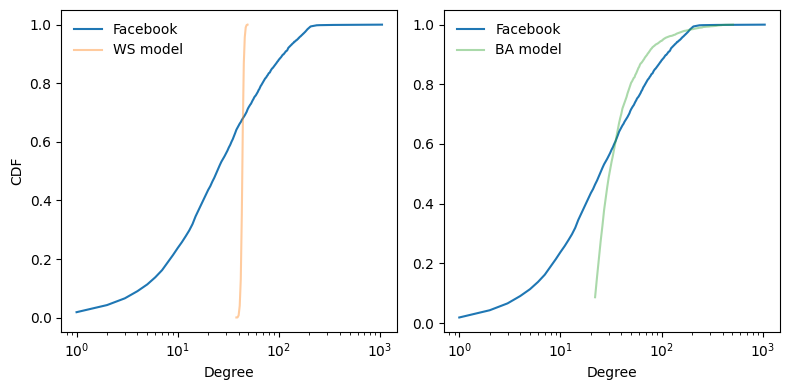

In [56]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
cdf_fb.plot(color='C0')
cdf_ws.plot(color='C1', alpha=0.4)
decorate(xlabel='Degree', xscale='log',
                 ylabel='CDF')

plt.subplot(1,2,2)
cdf_fb.plot(color='C0', label='Facebook')
cdf_ba.plot(color='C2', alpha=0.4)
decorate(xlabel='Degree', xscale='log')

savefig('figs/chap04-4')

Clearly the CDF for the WS model is very different from the CDF from the data. The BA model is better, but still not very good, especially for small values.

In the tail of the distribution (values greater than 100) it looks like the BA model matches the dataset well enough, but it is hard to see. We can get a clearer view with one other view of the data: plotting the complementary CDF on a log-log scale.

The **complementary CDF** (CCDF) is defined $$\mathrm{CCDF}(x) \equiv 1 - \mathrm{CDF}(x)$$ This definition is useful because if the PMF follows a power law, the CCDF also follows a power law: $$\mathrm{CCDF}(x) \sim \left( \frac{x}{x_m} \right)^{-\alpha}$$ where $x_m$ is the minimum possible value and $\alpha$ is a parameter that determines the shape of the distribution.

Taking the log of both sides yields: $$\log \mathrm{CCDF}(x) \sim -\alpha (\log x - \log x_m)$$ So if the distribution obeys a power law, we expect the CCDF on a log-log scale to be a straight line with slope $-\alpha$.

The following figure shows the CCDF of degree for the Facebook data, along with the WS model (left) and the BA model (right), on a log-log scale.

Saving figure to file figs/chap04-5


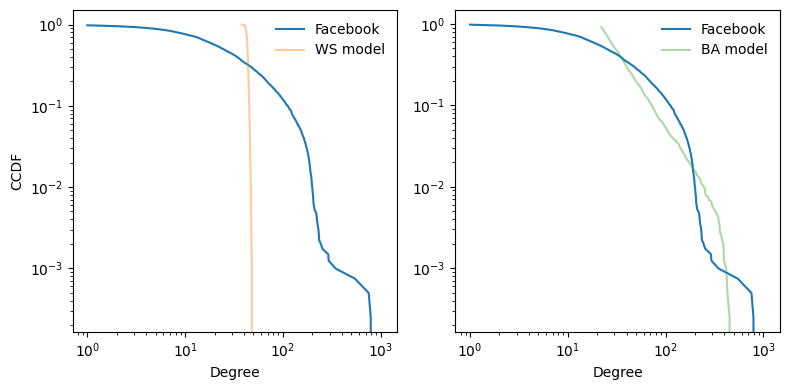

In [57]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
(1 - cdf_fb).plot(color='C0')
(1 - cdf_ws).plot(color='C1', alpha=0.4)
decorate(xlabel='Degree', xscale='log',
                 ylabel='CCDF', yscale='log')

plt.subplot(1,2,2)

(1 - cdf_fb).plot(color='C0', label='Facebook')
(1 - cdf_ba).plot(color='C2', alpha=0.4)
decorate(xlabel='Degree', xscale='log',
                 yscale='log')

savefig('figs/chap04-5')

With this way of looking at the data, we can see that the BA model matches the tail of the distribution (values above 20) reasonably well. The WS model does not.

But there is certainly room for a model that does a better job of fitting the whole distribution.

## Explanatory models

We started the discussion of networks with Milgram's Small World Experiment, which shows that path lengths in social networks are surprisingly small; hence, "six degrees of separation".

When we see something surprising, it is natural to ask "Why?" but sometimes it's not clear what kind of answer we are looking for. One kind of answer is an **explanatory model**, which has the logical structure shown in the following figure.

![The logical structure of an explanatory model.](https://github.com/AllenDowney/ThinkComplexity/raw/v3/images/model.png)

The logical structure of an explanatory model is:

1.  In a system, S, we see something observable, O, that warrants explanation.

2.  We construct a model, M, that is analogous to the system; that is, there is a correspondence between the elements of the model and the elements of the system.

3.  By simulation or mathematical derivation, we show that the model exhibits a behavior, B, that is analogous to O.

4.  We conclude that S exhibits O *because* S is similar to M, M exhibits B, and B is similar to O.

At its core, this is an argument by analogy, which says that if two things are similar in some ways, they are likely to be similar in other ways.

Argument by analogy can be useful, and explanatory models can be satisfying, but they do not constitute a proof in the mathematical sense of the word.

Remember that all models leave out, or "abstract away", details that we think are unimportant. For any system there are many possible models that include or ignore different features. And there might be models that exhibit different behaviors that are similar to O in different ways. In that case, which model explains O?

The small world phenomenon is an example: the Watts-Strogatz (WS) model and the Barabási-Albert (BA) model both exhibit elements of small world behavior, but they offer different explanations:

-   The WS model suggests that social networks are "small" because they include both strongly-connected clusters and "weak ties" that connect clusters (see <https://thinkcomplex.com/weak>).

-   The BA model suggests that social networks are small because they include nodes with high degree that act as hubs, and that hubs grow, over time, due to preferential attachment.

As is often the case in young areas of science, the problem is not that we have no explanations, but too many.

## Exercises

**Exercise:** In the "Explanatory models" section we discussed two explanations for the small world phenomenon, "weak ties" and "hubs". Are these explanations compatible; that is, can they both be right? Which do you find more satisfying as an explanation, and why?

Is there data you could collect, or experiments you could perform, that would provide evidence in favor of one model over the other?

Choosing among competing models is the topic of Thomas Kuhn's essay, "Objectivity, Value Judgment, and Theory Choice", which you can read at <https://thinkcomplex.com/kuhn>.

What criteria does Kuhn propose for choosing among competing models? Do these criteria influence your opinion about the WS and BA models? Are there other criteria you think should be considered?

**Exercise:** Data files from the Barabasi and Albert paper are available from
[this web page](https://web.archive.org/web/20150910025718/http://www3.nd.edu/~networks/resources.htm).

Their actor collaboration data is included in the repository for this book in a file named
`actor.dat.gz`.  The following function reads the file and builds the graph.

In [58]:
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/data/actor.dat.gz')

In [59]:
import gzip

def read_actor_network(filename, n=None):
    """Reads graph data from a file.
    
    filename: string
    n: int, number of lines to read (default is all)
    """
    G = nx.Graph()
    with gzip.open(filename) as f:
        for i, line in enumerate(f):
            nodes = [int(x) for x in line.split()]
            G.add_edges_from(all_pairs(nodes))
            if n and i >= n:
                break
    return G

In [60]:
def all_pairs(nodes):
    """Generates all pairs of nodes."""
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i < j:
                yield u, v

Compute the number of actors in the graph and the number of edges.

Check whether this graph has the small world properties, high clustering and low
path length.

Plot the PMF of degree on a log-log scale.  Does it seem to follow a power law?

Also plot the CDF of degree on a log-x scale, to 
see the general shape of the distribution, and on a log-log scale, to see whether 
the tail follows a power law.

Note: The actor network is not connected, so you might want to use
`nx.connected_components` to find connected subsets of the
nodes.

In [61]:
# WARNING: if you run this with larger values of `n`, you
# might run out of memory, and Jupyter does not handle that well.

%time actors = read_actor_network('actor.dat.gz', n=10000)
len(actors)

CPU times: user 620 ms, sys: 12.1 ms, total: 632 ms
Wall time: 638 ms


17540

In [62]:
# Solution

# As expected, the average clustering is high

average_clustering(actors, trials=10000)

0.7308

In [63]:
# Solution

# And in the largest connected component, the average path length is low

for nodes in nx.connected_components(actors):
    if len(nodes) > 100:
        print(len(nodes), estimate_path_length(actors, nodes))

17270 3.542


In [64]:
# Solution

# Here are the mean and standard deviation of degree:

ds = degrees(actors)
np.mean(ds), np.std(ds)

(np.float64(38.35541619156214), np.float64(61.53610074821354))

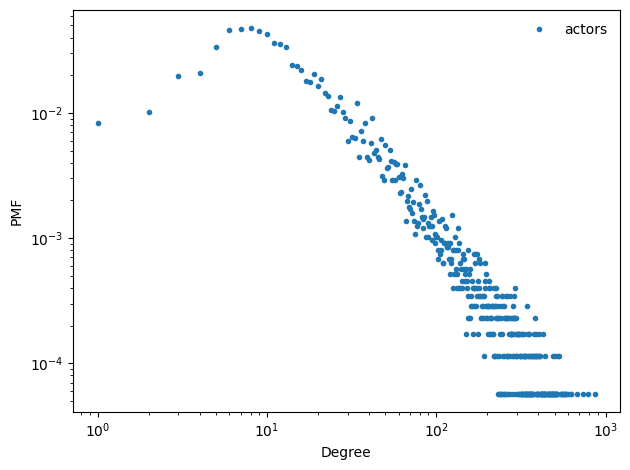

In [65]:
# Solution

# And the PMF of degree on a log-log scale

pmf = Pmf.from_seq(ds, name='actors')
pmf.plot(**options)
decorate(xlabel='Degree', ylabel='PMF',
         xscale='log', yscale='log')

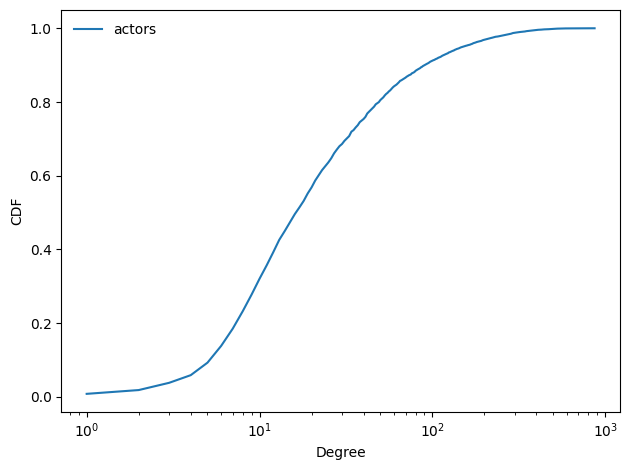

In [66]:
# Solution

# Here's the CDF on a log scale

cdf = Cdf.from_seq(ds, name='actors')
cdf.plot()
decorate(xlabel='Degree', ylabel='CDF', xscale='log')

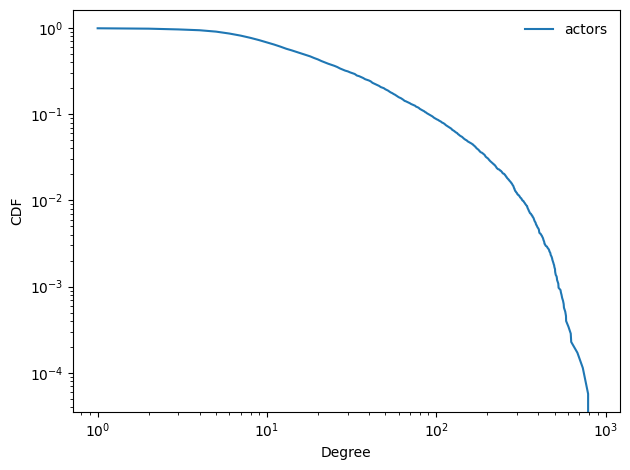

In [67]:
# Solution

# and the CDF on a log-log scale

(1-cdf).plot()
decorate(xlabel='Degree', ylabel='CDF',
                 xscale='log', yscale='log')

In [68]:
# Solution

# The PMF on a log-log scale suggests a power law.

# The CDF on a log-x scale looks like a lognormal distribution, possibly
# skewed to the right.

# The CDF on a log-log scale does not have the straight line behavior
# we expect from a power law, but it is consistent with a heavy-tailed
# distribution.

**Exercise:** NetworkX provides a function called `powerlaw_cluster_graph` that implements the "Holme and Kim algorithm for growing graphs with powerlaw degree distribution and approximate average clustering".  Read the documentation of this function (<https://thinkcomplex.com/hk>) and see if you can use it to generate a graph that has the same number of nodes as the Facebook network, the same average degree, and the same clustering coefficient.  How does the degree distribution in the model compare to the actual distribution?

In [69]:
# Again, here are the parameters of the Facebook data

n = len(fb)
m = len(fb.edges())
k = int(round(m / n))
n, m, k

(4039, 88234, 22)

In [70]:
# Solution

# Now we can make an HK graph with these parameters,
# and with the target clustering as high as possible.

hk = nx.powerlaw_cluster_graph(n, k, 1.0, seed=15)
len(hk), len(hk.edges())

(4039, 88363)

In [71]:
# Solution

# The average clustering is much higher than in the BA
# model, but still not as high as in the data.

C, average_clustering(hk)

(0.607, 0.281)

In [72]:
# Solution

# The average path length is even lower than in the data.

L, estimate_path_length(hk)

(np.float64(3.717), np.float64(2.795))

In [73]:
# Solution

# The mean degree is about right.

np.mean(degrees(fb)), np.mean(degrees(hk))

(np.float64(43.69101262688784), np.float64(43.75488982421391))

In [74]:
# Solution

# The standard deviation of degree is a little low

np.std(degrees(fb)), np.std(degrees(hk))

(np.float64(52.41411556737521), np.float64(43.106377456263075))

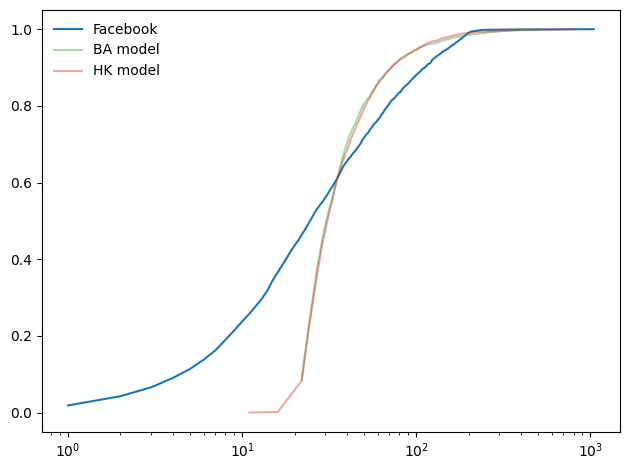

In [75]:
# Solution

# The degree distribution is almost identical to the BA model

cdf_hk = Cdf.from_seq(degrees(hk), name='HK model')
cdf_fb.plot(color='C0')
cdf_ba.plot(color='C2', alpha=0.4)
cdf_hk.plot(color='C3', alpha=0.4)
decorate(xscale='log')

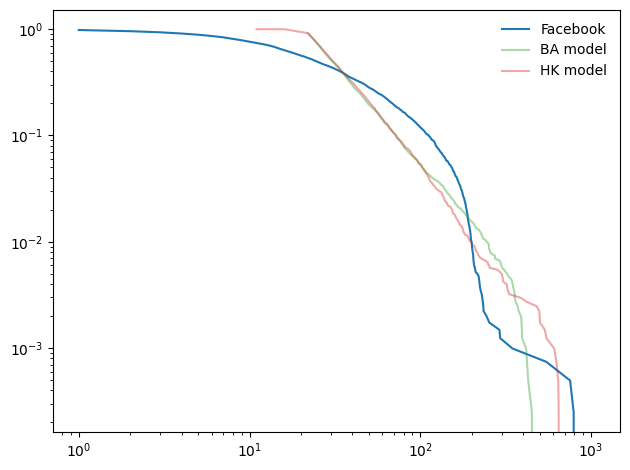

In [76]:
# Solution

# On a log-log scale, both HK and BA are reasonable
# models for the tail behavior.

(1-cdf_fb).plot()
(1-cdf_ba).plot(color='C2', alpha=0.4)
(1-cdf_hk).plot(color='C3', alpha=0.4)
decorate(xscale='log', yscale='log', loc='upper right')


[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)